In [2]:
# ==========================================================
# CELL 1 : Import Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================================
# CELL 3 : Load Dataset
# ==========================================================

train = pd.read_csv('/content/drive/MyDrive/Drugs_Review_Datasets/drugLibTrain_raw.tsv', sep='\t')

test = pd.read_csv('/content/drive/MyDrive/Drugs_Review_Datasets/drugLibTest_raw.tsv', sep='\t')

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (3107, 9)
Test Shape  : (1036, 9)


In [4]:
#  checking the head of the train

train.head()


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [5]:
test.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,The antibiotic may have destroyed bacteria cau...,"Some back pain, some nauseau.",Took the antibiotics for 14 days. Sinus infect...
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,Lamictal stabilized my serious mood swings. On...,"Drowsiness, a bit of mental numbness. If you t...",Severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,Initial benefits were comparable to the brand ...,"Depakene has a very thin coating, which caused...",Depakote was prescribed to me by a Kaiser psyc...
3,969,sarafem,10,Highly Effective,No Side Effects,bi-polar / anxiety,It controlls my mood swings. It helps me think...,I didnt really notice any side effects.,This drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,Mild Side Effects,nodular acne,Within one week of treatment superficial acne ...,Side effects included moderate to severe dry s...,Drug was taken in gelatin tablet at 0.5 mg per...


In [6]:
# ==========================================================
# Combine Train and Test Dataset
# ==========================================================

data = pd.concat(
    [train, test],
    axis=0,
    ignore_index=True
)

print("Combined Shape:", data.shape)

Combined Shape: (4143, 9)


In [7]:
# ==========================================================
# Random Sample Records
# ==========================================================

display(data.sample(5, random_state=42))

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2351,2260,lexapro,1,Marginally Effective,Severe Side Effects,anxiety,"Initially, Lexapro helped alleviate some of th...","Although some stress was alleviated, I noticed...",I took approximately 5mg a day. I visited my d...
1966,2324,lexapro,10,Highly Effective,No Side Effects,general depression/perimenopause,Started taking this drug for two reasons - per...,"Fortunately, none for me. I know this type of ...","Started out with a very low dose, 5mg/day for ..."
1582,2858,albuterol,9,Highly Effective,Mild Side Effects,asthma,short term relief from breathing problems. esp...,sometimes dry mouth but usually not to severe,patient had occasional breathing problems that...
296,3456,tamiflu,10,Highly Effective,Mild Side Effects,swine flu,'Was diagnosed with H1N1 and was ill for at li...,I think I remember not being able to taste ver...,Prescribed Tamiflu for 5 days (one capsule twi...
149,4075,mobic,1,Ineffective,No Side Effects,back pain,No impact whatsoever. It was like I wasn't ev...,"None. Seriously, I could not even tell I had ...","Took 2 tablets (15 mg) total, once daily in th..."


In [8]:
# ==========================================================
# Numerical Summary
# ==========================================================

display(data.describe())

,Unnamed: 0,rating
count,4143.000000,4143.000000
mean,2081.808834,6.946416
std,1202.018138,2.948868
min,0.000000,1.000000
25%,1041.500000,5.000000
50%,2083.000000,8.000000
75%,3123.500000,9.000000
max,4161.000000,10.000000


In [9]:
# ==========================================================
# Dataset Information
# ==========================================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4143 entries, 0 to 4142
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4143 non-null   int64 
 1   urlDrugName        4143 non-null   object
 2   rating             4143 non-null   int64 
 3   effectiveness      4143 non-null   object
 4   sideEffects        4143 non-null   object
 5   condition          4142 non-null   object
 6   benefitsReview     4120 non-null   object
 7   sideEffectsReview  4045 non-null   object
 8   commentsReview     4130 non-null   object
dtypes: int64(2), object(7)
memory usage: 291.4+ KB


In [10]:
# ==========================================================
# Remove Unnecessary Column
# ==========================================================

data.drop(
    columns=["Unnamed: 0"],
    inplace=True
)

print(data.shape)

(4143, 8)


In [11]:
# ==========================================================
# Missing Values Analysis
# ==========================================================

missing_df = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage":round(data.isnull().mean() * 100,2)
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_df)

,Missing Count,Missing Percentage
sideEffectsReview,98,2.37
benefitsReview,23,0.56
commentsReview,13,0.31
condition,1,0.02
sideEffects,0,0.00
effectiveness,0,0.00
rating,0,0.00
urlDrugName,0,0.00


In [12]:
# ==========================================================
# Handle Missing Values
# ==========================================================

# Fill missing condition
data["condition"] = data["condition"].fillna("Unknown")

# Fill missing text reviews
data["benefitsReview"] = data["benefitsReview"].fillna("")

data["sideEffectsReview"] = data["sideEffectsReview"].fillna("")

data["commentsReview"] = data["commentsReview"].fillna("")

# Verify
print("Remaining Missing Values")

print(data.isnull().sum())

Remaining Missing Values
urlDrugName          0
rating               0
effectiveness        0
sideEffects          0
condition            0
benefitsReview       0
sideEffectsReview    0
commentsReview       0
dtype: int64


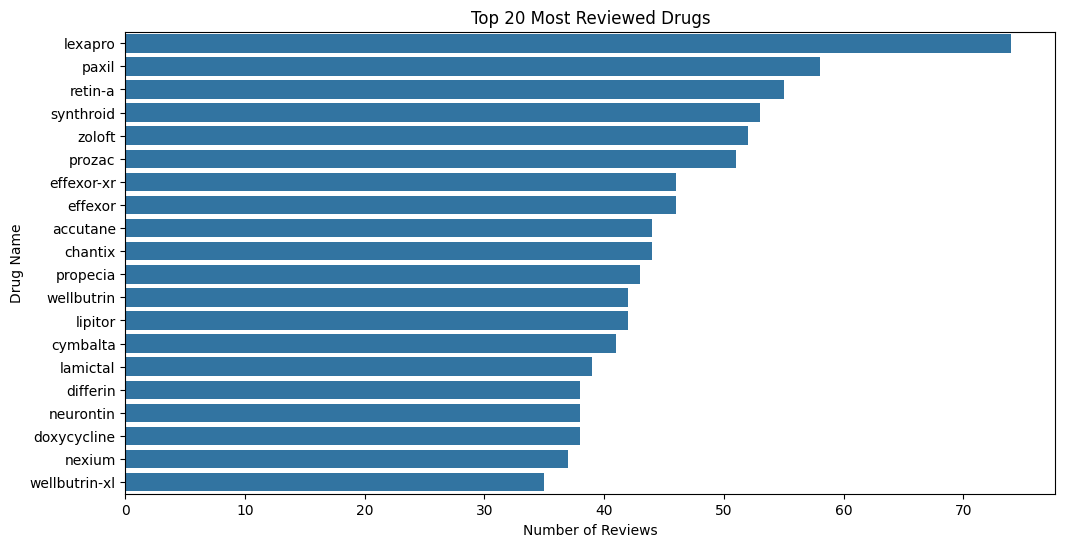

In [13]:
# ==========================================================
# Top 20 Most Reviewed Drugs
# ==========================================================

top_drugs = (
    data["urlDrugName"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_drugs.values,
    y=top_drugs.index
)

plt.title(
    "Top 20 Most Reviewed Drugs"
)

plt.xlabel("Number of Reviews")

plt.ylabel("Drug Name")

plt.show()

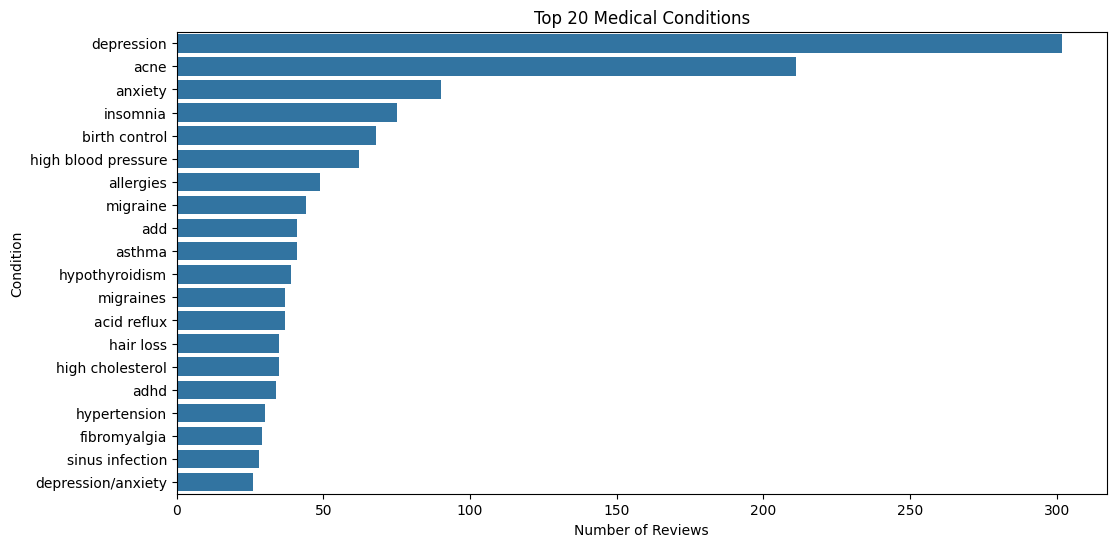

In [14]:
# ==========================================================
# Top Conditions
# ==========================================================

top_conditions = (
    data["condition"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index
)

plt.title(
    "Top 20 Medical Conditions"
)

plt.xlabel("Number of Reviews")

plt.ylabel("Condition")

plt.show()

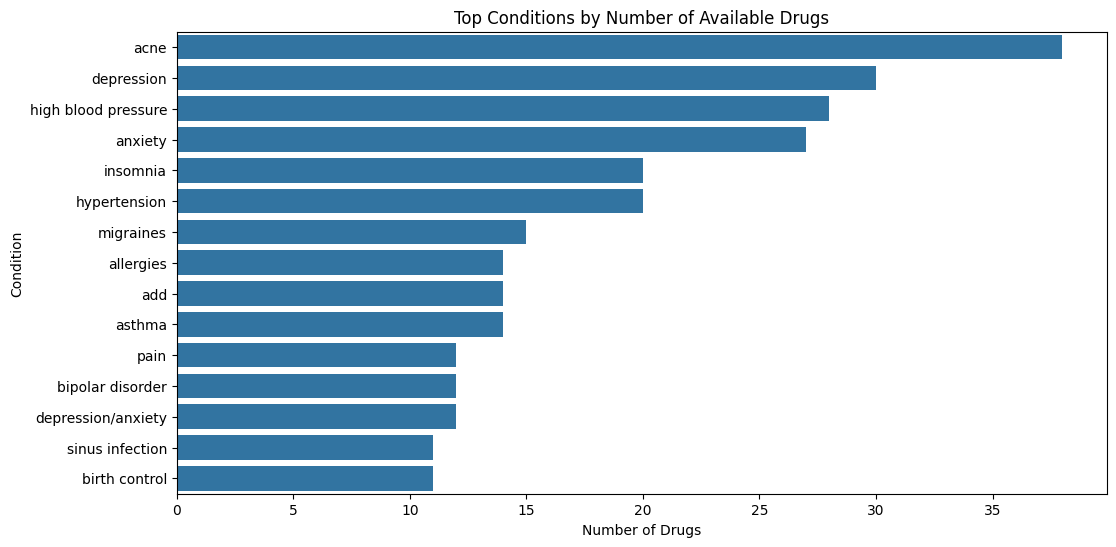

In [15]:
# ==========================================================
# Top Conditions by Number of Available Drugs
# ==========================================================

top_conditions = (
    data.groupby("condition")["urlDrugName"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index
)

plt.title(
    "Top Conditions by Number of Available Drugs"
)

plt.xlabel("Number of Drugs")

plt.ylabel("Condition")

plt.show()

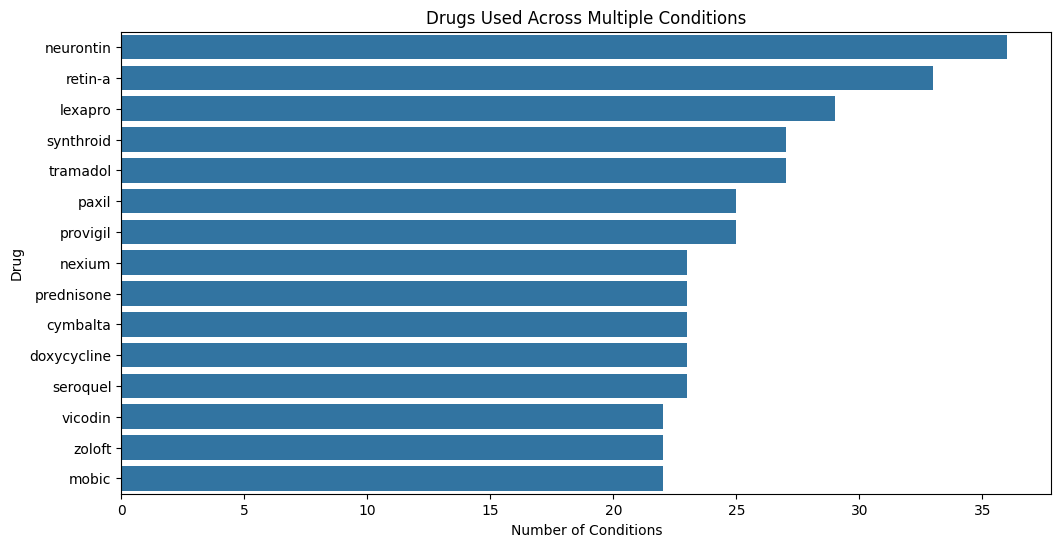

In [16]:
# ==========================================================
# Top Drugs Used Across Multiple Conditions
# ==========================================================

top_drugs = (
    data.groupby("urlDrugName")["condition"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_drugs.values,
    y=top_drugs.index
)

plt.title(
    "Drugs Used Across Multiple Conditions"
)

plt.xlabel("Number of Conditions")

plt.ylabel("Drug")

plt.show()

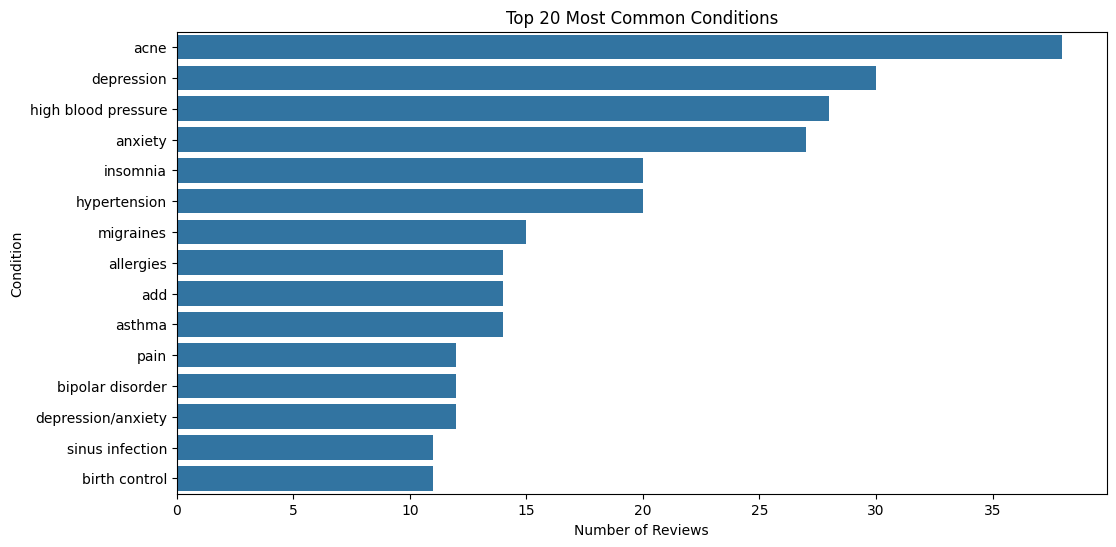

In [17]:
# ==========================================================
# Top 20 Most Common Conditions
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index
)

plt.title(
    "Top 20 Most Common Conditions"
)

plt.xlabel("Number of Reviews")

plt.ylabel("Condition")

plt.show()

In [18]:
# ==========================================================
# Sample Review Analysis
# ==========================================================

sample_row = 0

print("Condition:")
print(data["condition"].iloc[sample_row])

print("\nDrug:")
print(data["urlDrugName"].iloc[sample_row])

print("\nBenefits Review:")
print(data["benefitsReview"].iloc[sample_row])

print("\nSide Effects Review:")
print(data["sideEffectsReview"].iloc[sample_row])

print("\nComments Review:")
print(data["commentsReview"].iloc[sample_row])

Condition:
management of congestive heart failure

Drug:
enalapril

Benefits Review:


mangagement of congestive heart failur

Side Effects Review:
cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness

Comments Review:
monitor blood pressure , weight and asses for resolution of fluid


In [19]:
# ==========================================================
# Rating Distribution
# ==========================================================

rating_counts = (
    data["rating"]
    .value_counts()
    .sort_index()
)

display(rating_counts)

,count
rating,
1,420
2,136
3,195
4,151
5,226
6,215
7,471
8,748
9,613


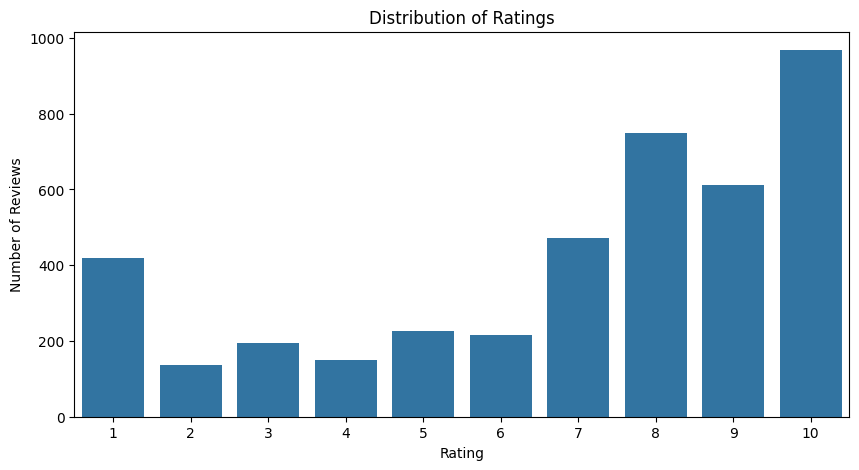

In [20]:
# ==========================================================
# Rating Distribution Visualization
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="rating",
    data=data
)

plt.title("Distribution of Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.show()

In [21]:
print(data["effectiveness"].value_counts())

effectiveness
Highly Effective          1741
Considerably Effective    1238
Moderately Effective       572
Ineffective                329
Marginally Effective       263
Name: count, dtype: int64


In [22]:
print(data["sideEffects"].value_counts())

sideEffects
Mild Side Effects                1349
No Side Effects                  1198
Moderate Side Effects             850
Severe Side Effects               491
Extremely Severe Side Effects     255
Name: count, dtype: int64


In [23]:
# ==========================================================
# Create Effectiveness Score
# ==========================================================

effectiveness_mapping = {
    "Highly Effective": 5,
    "Considerably Effective": 4,
    "Moderately Effective": 3,
    "Marginally Effective": 2,
    "Ineffective": 1
}

data["effectiveness_score"] = (
    data["effectiveness"]
    .map(effectiveness_mapping)
)

# Verify
display(
    data[
        ["effectiveness",
         "effectiveness_score"]
    ].head()
)

,effectiveness,effectiveness_score
0,Highly Effective,5
1,Highly Effective,5
2,Highly Effective,5
3,Marginally Effective,2
4,Marginally Effective,2


In [24]:
# ==========================================================
# Create Side Effect Score
# ==========================================================

side_effect_mapping = {
    "No Side Effects": 5,
    "Mild Side Effects": 4,
    "Moderate Side Effects": 3,
    "Severe Side Effects": 2,
    "Extremely Severe Side Effects": 1
}

data["side_effect_score"] = (
    data["sideEffects"]
    .map(side_effect_mapping)
)

# Verify
display(
    data[
        ["sideEffects",
         "side_effect_score"]
    ].head()
)

,sideEffects,side_effect_score
0,Mild Side Effects,4
1,Severe Side Effects,2
2,No Side Effects,5
3,Mild Side Effects,4
4,Severe Side Effects,2


In [25]:
# ==========================================================
# Convert Rating to 1-5 Scale
# ==========================================================

data["rating_score"] = (
    data["rating"] / 2
)

display(
    data[
        ["rating",
         "rating_score"]
    ].head()
)

,rating,rating_score
0,4,2.0
1,1,0.5
2,10,5.0
3,3,1.5
4,2,1.0


In [26]:
# ==========================================================
# Feature Engineering
# Create Review Sentiment
# ==========================================================

data["Review_Sentiment"] = (
    data["rating"] >= 5
).astype(int)

display(
    data["Review_Sentiment"]
    .value_counts()
)

,count
Review_Sentiment,
1,3241
0,902


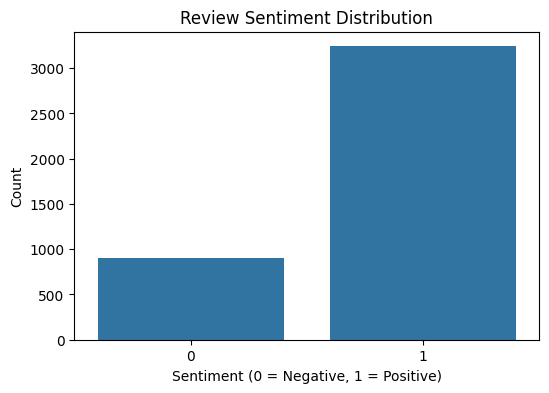

In [27]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Review_Sentiment",
    data=data
)

plt.title("Review Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")

plt.show()

In [28]:
# ==========================================================
# Feature Engineering
# Review Length Features
# ==========================================================

data["benefits_length"] = (
    data["benefitsReview"]
    .fillna("")
    .str.len()
)

data["sideeffects_length"] = (
    data["sideEffectsReview"]
    .fillna("")
    .str.len()
)

data["comments_length"] = (
    data["commentsReview"]
    .fillna("")
    .str.len()
)

display(
    data[
        [
            "benefits_length",
            "sideeffects_length",
            "comments_length"
        ]
    ].head()
)

,benefits_length,sideeffects_length,comments_length
0,184,197,65
1,178,258,62
2,254,42,387
3,598,111,158
4,114,150,9


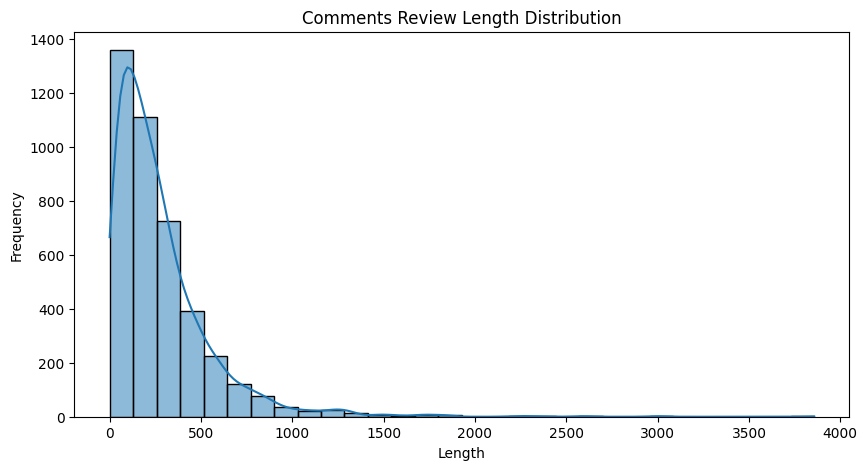

In [29]:
# ==========================================================
# Review Length Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data["comments_length"],
    bins=30,
    kde=True
)

plt.title("Comments Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

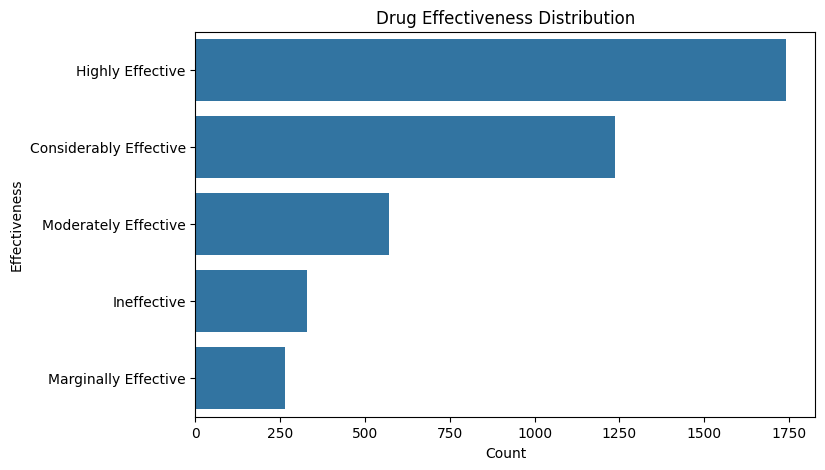

In [30]:
# ==========================================================
# Effectiveness Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    y="effectiveness",
    data=data,
    order=data["effectiveness"].value_counts().index
)

plt.title("Drug Effectiveness Distribution")
plt.xlabel("Count")
plt.ylabel("Effectiveness")

plt.show()

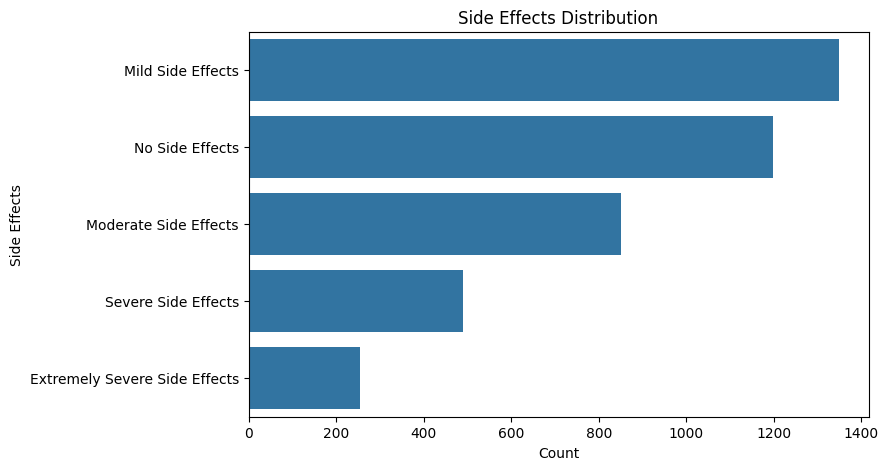

In [31]:
# ==========================================================
# Side Effects Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    y="sideEffects",
    data=data,
    order=data["sideEffects"].value_counts().index
)

plt.title("Side Effects Distribution")
plt.xlabel("Count")
plt.ylabel("Side Effects")

plt.show()

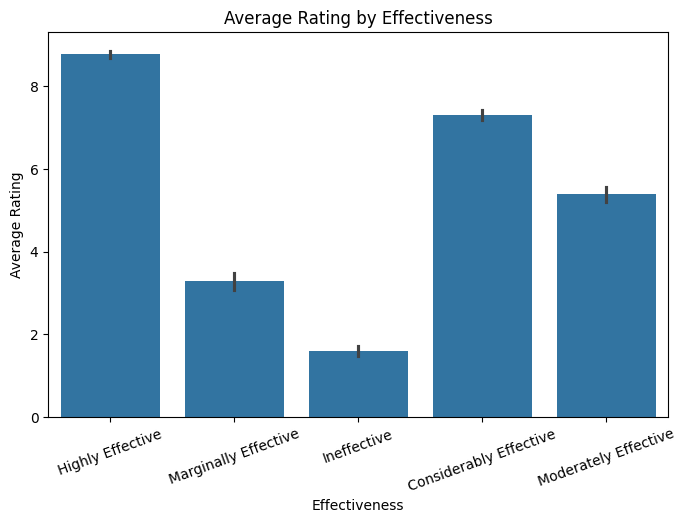

In [32]:
# ==========================================================
# Average Rating by Effectiveness
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="effectiveness",
    y="rating",
    data=data
)

plt.title("Average Rating by Effectiveness")
plt.xlabel("Effectiveness")
plt.ylabel("Average Rating")

plt.xticks(rotation=20)

plt.show()

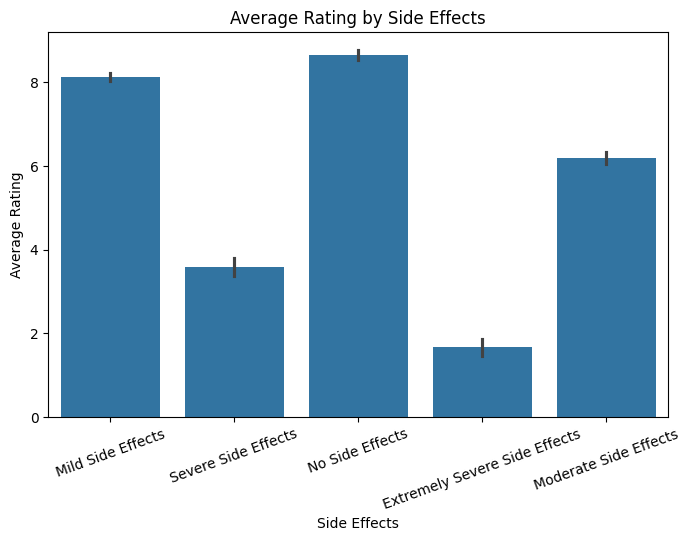

In [33]:
# ==========================================================
# Average Rating by Side Effects
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="sideEffects",
    y="rating",
    data=data
)

plt.title("Average Rating by Side Effects")
plt.xlabel("Side Effects")
plt.ylabel("Average Rating")

plt.xticks(rotation=20)

plt.show()

In [34]:
# ==========================================================
# Import NLP Libraries
# ==========================================================

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [35]:
# ==========================================================
# Combine Review Columns
# ==========================================================

data["combined_review"] = (
    data["benefitsReview"] + " " +
    data["sideEffectsReview"] + " " +
    data["commentsReview"]
)

display(
    data[
        [
            "combined_review"
        ]
    ].head()
)

,combined_review
0,slowed the progression of left ventricular dys...
1,Although this type of birth control has more c...
2,I was used to having cramps so badly that they...
3,The acid reflux went away for a few months aft...
4,I think that the Lyrica was starting to help w...


In [36]:
# ==========================================================
# Stopword List
# ==========================================================

stop_words = set(
    stopwords.words("english")
)

print(
    "Total Stopwords:",
    len(stop_words)
)

Total Stopwords: 198


In [37]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    words = []

    for word in text.split():

        if word not in stop_words:

            words.append(
                lemmatizer.lemmatize(word)
            )

    return " ".join(words)

In [38]:
# ==========================================================
# Apply Text Cleaning
# ==========================================================

data["clean_review"] = (
    data["combined_review"]
    .apply(clean_text)
)

display(
    data[
        [
            "combined_review",
            "clean_review"
        ]
    ].head()
)

,combined_review,clean_review
0,slowed the progression of left ventricular dys...,slowed progression left ventricular dysfunctio...
1,Although this type of birth control has more c...,although type birth control con pro help cramp...
2,I was used to having cramps so badly that they...,used cramp badly would leave balled bed least ...
3,The acid reflux went away for a few months aft...,acid reflux went away month day drug heartburn...
4,I think that the Lyrica was starting to help w...,think lyrica starting help pain sideeffects se...


In [39]:
# ==========================================================
# Review Length After Cleaning
# ==========================================================

data["clean_review_length"] = (
    data["clean_review"]
    .str.len()
)

display(
    data[
        [
            "clean_review_length"
        ]
    ].head()
)

,clean_review_length
0,368
1,317
2,418
3,526
4,164


In [40]:
# ==========================================================
# Drug Level Aggregation
# ==========================================================

drug_features = (
    data.groupby("urlDrugName")
    .agg(
        avg_rating=("rating_score", "mean"),
        avg_effectiveness=("effectiveness_score", "mean"),
        avg_side_effect=("side_effect_score", "mean"),
        review_count=("urlDrugName", "count")
    )
    .reset_index()
)

display(drug_features.head())

,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count
0,abilify,2.687500,3.625000,3.500000,8
1,acanya,4.500000,5.000000,4.000000,1
2,accolate,0.500000,1.000000,5.000000,1
3,accupril,4.500000,4.000000,5.000000,1
4,accutane,3.863636,4.522727,3.136364,44


In [41]:
# ==========================================================
# Recommendation Score
# ==========================================================

drug_features["recommendation_score"] = (
    0.4 * drug_features["avg_effectiveness"]
    + 0.3 * drug_features["avg_rating"]
    + 0.3 * drug_features["avg_side_effect"]
)

drug_features.sort_values(
    by="recommendation_score",
    ascending=False,
    inplace=True
)

display(drug_features.head(10))

,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,recommendation_score
502,vigamox,5.0,5.0,5.0,1,5.0
485,triphasil,5.0,5.0,5.0,3,5.0
453,taclonex,5.0,5.0,5.0,1,5.0
402,qvar,5.0,5.0,5.0,1,5.0
524,zestoretic,5.0,5.0,5.0,1,5.0
178,erythra-derm,5.0,5.0,5.0,1,5.0
163,dyazide,5.0,5.0,5.0,1,5.0
186,eulexin,5.0,5.0,5.0,1,5.0
211,fosamax-plus-d,5.0,5.0,5.0,1,5.0
327,nordette,5.0,5.0,5.0,1,5.0


In [42]:
# ==========================================================
# TF-IDF Vectorization
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(
    data["clean_review"]
)

print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (4143, 10000)


In [43]:
# ==========================================================
# Cosine Similarity
# ==========================================================

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    tfidf_matrix
)

print(similarity_matrix.shape)

(4143, 4143)


In [44]:
# ==========================================================
# Create Drug Profile
# ==========================================================

drug_profiles = (
    data.groupby("urlDrugName")["clean_review"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

drug_profiles.head()

,urlDrugName,clean_review
0,abilify,abilify honestly say depression resolved cause...
1,acanya,acanya gel treated cystic acne blackhead white...
2,accolate,benefit good drug expensive effective problem ...
3,accupril,lower blood pressure combination hyzaar none a...
4,accutane,eventually cleared moderate acne recieved anti...


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

drug_tfidf = tfidf.fit_transform(
    drug_profiles["clean_review"]
)

drug_similarity = cosine_similarity(
    drug_tfidf
)

print(drug_similarity.shape)

(541, 541)


In [46]:
drug_indices = pd.Series(
    drug_profiles.index,
    index=drug_profiles["urlDrugName"]
).drop_duplicates()

drug_indices.head()

,0
urlDrugName,
abilify,0
acanya,1
accolate,2
accupril,3
accutane,4


In [47]:
drug_rating = (
    data.groupby("urlDrugName")["rating_score"]
    .mean()
    .reset_index()
)

drug_profiles = drug_profiles.merge(
    drug_rating,
    on="urlDrugName",
    how="left"
)

In [48]:
def recommend_drugs(drug_name, top_n=5):

    idx = drug_indices[drug_name]

    sim_scores = list(enumerate(drug_similarity[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:21]

    drug_ids = [i[0] for i in sim_scores]

    result = drug_profiles.iloc[drug_ids][
        ["urlDrugName", "rating_score"]
    ].copy()

    result["similarity_score"] = [
        i[1] for i in sim_scores
    ]

    # Combined ranking
    result["final_score"] = (
        0.7 * result["similarity_score"]
        + 0.3 * result["rating_score"] / 5
    )

    result = result.sort_values(
        "final_score",
        ascending=False
    )

    return result.head(top_n)

In [49]:
import pickle

pickle.dump(
    drug_similarity,
    open("drug_similarity.pkl", "wb")
)

pickle.dump(
    drug_profiles,
    open("drug_profiles.pkl", "wb")
)

In [50]:
drug_profiles["urlDrugName"].sample(10)

,urlDrugName
147,differin
387,progesterone
417,rhinocort
53,avapro
415,retin-a
430,septra
335,nystatin
105,cleocin
464,tenormin
471,topicort


In [51]:
recommend_drugs(
    "dostinex",
    top_n=5
)

,urlDrugName,rating_score,similarity_score,final_score
353,parlodel,4.250000,0.402153,0.536507
259,levothroid,4.833333,0.109226,0.366458
313,nardil,4.500000,0.120362,0.354253
511,wellbutrin,3.595238,0.149751,0.320540
426,sarafem,3.884615,0.123306,0.319391


# Condition-Based Drug Recommendation

In [52]:
# ==========================================================
# Create Drug Summary Table
# ==========================================================
# Goal:
# For every Condition + Drug combination,
# calculate average rating, total reviews,
# and average review length.

drug_summary = (
    data.groupby(
        ["condition", "urlDrugName"]
    )
    .agg(

        # Average rating given by users
        avg_rating=("rating_score", "mean"),

        # Number of reviews available
        review_count=("clean_review", "count"),

        # Average review length
        avg_review_length=("clean_review_length", "mean")

    )
    .reset_index()
)

# Display first few rows
drug_summary.head()

,condition,urlDrugName,avg_rating,review_count,avg_review_length
0,1mg,propecia,4.5,1,713.0
1,2,aricept,4.5,1,323.0
2,2 broken arms,mobic,4.5,1,406.0
3,2 compressed discs in neck,tramadol,4.5,1,322.0
4,20 year pack a day smoker,chantix,5.0,1,416.0


In [53]:
data.columns

Index(['urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition',
       'benefitsReview', 'sideEffectsReview', 'commentsReview',
       'effectiveness_score', 'side_effect_score', 'rating_score',
       'Review_Sentiment', 'benefits_length', 'sideeffects_length',
       'comments_length', 'combined_review', 'clean_review',
       'clean_review_length'],
      dtype='object')

In [54]:
# ==========================================================
# Number of unique conditions
# ==========================================================

print("Unique Conditions:", data["condition"].nunique())

# ==========================================================
# Number of unique drugs
# ==========================================================

print("Unique Drugs:", data["urlDrugName"].nunique())

Unique Conditions: 1808
Unique Drugs: 541


In [55]:
# ==========================================================
# Distribution of Condition Frequencies
# ==========================================================

condition_counts = data["condition"].value_counts()

print(condition_counts.describe())

count    1808.000000
mean        2.291482
std         9.986803
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       302.000000
Name: count, dtype: float64


In [56]:
# ==========================================================
# Top 20 Most Frequent Conditions
# ==========================================================

condition_counts.head(20)

,count
condition,
depression,302
acne,211
anxiety,90
insomnia,75
birth control,68
high blood pressure,62
allergies,49
migraine,44
add,41


In [57]:
# ==========================================================
# Conditions Having Only One Review
# ==========================================================

print(
    "Conditions with only 1 review:",
    (condition_counts == 1).sum()
)

Conditions with only 1 review: 1505


In [58]:
# ==========================================================
# Keep only conditions having at least 20 reviews
# ==========================================================

condition_counts = data["condition"].value_counts()

valid_conditions = condition_counts[
    condition_counts >= 20
].index

data_filtered = data[
    data["condition"].isin(valid_conditions)
].copy()

print("Original Shape :", data.shape)
print("Filtered Shape :", data_filtered.shape)
print("Valid Conditions :", len(valid_conditions))

Original Shape : (4143, 18)
Filtered Shape : (1489, 18)
Valid Conditions : 28


In [59]:
# ==========================================================
# Remaining Conditions
# ==========================================================

data_filtered["condition"].value_counts().head(30)

,count
condition,
depression,302
acne,211
anxiety,90
insomnia,75
birth control,68
high blood pressure,62
allergies,49
migraine,44
add,41


In [60]:
print("Total Remaining Conditions:",
      data_filtered["condition"].nunique())

Total Remaining Conditions: 28


In [61]:
condition_counts = data["condition"].value_counts()

for threshold in [2, 3, 5, 10, 20]:
    n_conditions = (condition_counts >= threshold).sum()

    print(
        f"Threshold {threshold}: "
        f"{n_conditions} conditions"
    )

Threshold 2: 303 conditions
Threshold 3: 181 conditions
Threshold 5: 103 conditions
Threshold 10: 56 conditions
Threshold 20: 28 conditions


In [62]:
# ==========================================================
# Enhanced Drug Summary Table
# ==========================================================
# Aggregate drug performance for every condition

drug_summary = (
    data.groupby(
        ["condition", "urlDrugName"]
    )
    .agg(

        # Average user rating
        avg_rating=("rating_score", "mean"),

        # Average effectiveness score
        avg_effectiveness=("effectiveness_score", "mean"),

        # Average side effect score
        avg_side_effect=("side_effect_score", "mean"),

        # Number of reviews
        review_count=("clean_review", "count"),

        # Average review length
        avg_review_length=("clean_review_length", "mean")

    )
    .reset_index()
)

drug_summary.head()

,condition,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,avg_review_length
0,1mg,propecia,4.5,4.0,4.0,1,713.0
1,2,aricept,4.5,5.0,5.0,1,323.0
2,2 broken arms,mobic,4.5,5.0,5.0,1,406.0
3,2 compressed discs in neck,tramadol,4.5,5.0,4.0,1,322.0
4,20 year pack a day smoker,chantix,5.0,5.0,4.0,1,416.0


In [63]:
# ==========================================================
# Normalize Features
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

drug_summary[
    [
        "rating_norm",
        "effectiveness_norm",
        "side_effect_norm",
        "review_count_norm",
        "review_length_norm"
    ]
] = scaler.fit_transform(
    drug_summary[
        [
            "avg_rating",
            "avg_effectiveness",
            "avg_side_effect",
            "review_count",
            "avg_review_length"
        ]
    ]
)

drug_summary.head()

,condition,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,avg_review_length,rating_norm,effectiveness_norm,side_effect_norm,review_count_norm,review_length_norm
0,1mg,propecia,4.5,4.0,4.0,1,713.0,0.888889,0.75,0.75,0.0,0.281212
1,2,aricept,4.5,5.0,5.0,1,323.0,0.888889,1.00,1.00,0.0,0.123636
2,2 broken arms,mobic,4.5,5.0,5.0,1,406.0,0.888889,1.00,1.00,0.0,0.157172
3,2 compressed discs in neck,tramadol,4.5,5.0,4.0,1,322.0,0.888889,1.00,0.75,0.0,0.123232
4,20 year pack a day smoker,chantix,5.0,5.0,4.0,1,416.0,1.000000,1.00,0.75,0.0,0.161212


In [64]:
# ==========================================================
# Create Final Recommendation Score
# ==========================================================

drug_summary["final_score"] = (

    # Most important factor
    0.35 * drug_summary["effectiveness_norm"]

    # User satisfaction
    + 0.25 * drug_summary["rating_norm"]

    # Lower side effects are better
    + 0.20 * drug_summary["side_effect_norm"]

    # More reviews increase confidence
    + 0.15 * drug_summary["review_count_norm"]

    # Small contribution from review quality
    + 0.05 * drug_summary["review_length_norm"]

)

drug_summary.head()

,condition,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,avg_review_length,rating_norm,effectiveness_norm,side_effect_norm,review_count_norm,review_length_norm,final_score
0,1mg,propecia,4.5,4.0,4.0,1,713.0,0.888889,0.75,0.75,0.0,0.281212,0.648783
1,2,aricept,4.5,5.0,5.0,1,323.0,0.888889,1.00,1.00,0.0,0.123636,0.778404
2,2 broken arms,mobic,4.5,5.0,5.0,1,406.0,0.888889,1.00,1.00,0.0,0.157172,0.780081
3,2 compressed discs in neck,tramadol,4.5,5.0,4.0,1,322.0,0.888889,1.00,0.75,0.0,0.123232,0.728384
4,20 year pack a day smoker,chantix,5.0,5.0,4.0,1,416.0,1.000000,1.00,0.75,0.0,0.161212,0.758061


In [65]:
# ==========================================================
# Recommendation Confidence
# ==========================================================

def get_confidence(review_count):

    if review_count >= 20:
        return "High"

    elif review_count >= 5:
        return "Medium"

    else:
        return "Low"


drug_summary["confidence"] = (
    drug_summary["review_count"]
    .apply(get_confidence)
)

In [66]:
# ==========================================================
# Condition Based Drug Recommendation
# ==========================================================

def recommend_by_condition(
    condition_name,
    top_n=5
):

    result = (
        drug_summary[
            drug_summary["condition"]
            .str.lower()
            ==
            condition_name.lower()
        ]
        .copy()
    )

    if len(result) == 0:

        return (
            f"No recommendations found "
            f"for '{condition_name}'"
        )

    result = result.sort_values(
        by="final_score",
        ascending=False
    )

    return result[
        [
            "urlDrugName",
            "avg_rating",
            "avg_effectiveness",
            "avg_side_effect",
            "review_count",
            "confidence",
            "final_score"
        ]
    ].head(top_n)

In [67]:
recommend_by_condition("anxiety")

,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,confidence,final_score
271,citalopram,5.000000,5.000000,4.000000,1,Low,0.756384
267,alprazolam,4.700000,4.600000,4.400000,5,Medium,0.742462
293,zoloft,4.700000,4.400000,4.000000,5,Medium,0.708558
292,xanax,3.961538,4.538462,3.923077,13,Medium,0.707925
272,clonazepam,4.500000,5.000000,3.500000,2,Low,0.707841


In [68]:
recommend_by_condition("depression")

,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,confidence,final_score
792,zyprexa,5.000000,5.000000,5.000000,1,Low,0.808929
782,prozac,3.750000,4.055556,3.805556,36,High,0.746994
772,elavil,5.000000,4.000000,5.000000,1,Low,0.716904
790,wellbutrin-xl,4.119048,3.904762,4.095238,21,High,0.705217
788,wellbutrin,3.733333,3.800000,3.900000,30,High,0.703138


In [69]:
recommend_by_condition("acne")

,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,confidence,final_score
47,eulexin,5.000000,5.000000,5.000000,1,Low,0.810949
45,erythra-derm,5.000000,5.000000,5.000000,1,Low,0.804848
32,accutane,3.903226,4.548387,3.225806,31,High,0.748299
51,klaron,4.500000,4.500000,5.000000,2,Low,0.734344
58,proloprim,4.500000,5.000000,4.000000,1,Low,0.733939


In [71]:
# ==========================================================
# Top Recommended Drugs Overall
# ==========================================================

drug_summary.sort_values(
    by="final_score",
    ascending=False
).head(20)

,condition,urlDrugName,avg_rating,avg_effectiveness,avg_side_effect,review_count,avg_review_length,rating_norm,effectiveness_norm,side_effect_norm,review_count_norm,review_length_norm,final_score,confidence,ranking_score
620,chronic back pain/depression/anxiety,cymbalta,5.0,5.0,5.0,1,1586.0,1.0,1.0,1.0,0.000000,0.633939,0.831697,Low,3.465736
1534,major depression,buprenorphine,5.0,5.0,5.0,1,1565.0,1.0,1.0,1.0,0.000000,0.625455,0.831273,Low,3.465736
329,"anxiety, panic disorder",valium,5.0,5.0,5.0,1,1322.0,1.0,1.0,1.0,0.000000,0.527273,0.826364,Low,3.465736
2277,shingles,valtrex,5.0,5.0,5.0,1,1226.0,1.0,1.0,1.0,0.000000,0.488485,0.824424,Low,3.465736
1579,menopause,combipatch,5.0,5.0,5.0,1,1164.0,1.0,1.0,1.0,0.000000,0.463434,0.823172,Low,3.465736
1906,panic disorder,xanax,5.0,5.0,5.0,2,864.0,1.0,1.0,1.0,0.028571,0.342222,0.821397,Low,5.493061
1517,low thyroid,tirosint,5.0,5.0,5.0,1,1072.0,1.0,1.0,1.0,0.000000,0.426263,0.821313,Low,3.465736
819,"depression, clinical level",zoloft,5.0,5.0,5.0,1,1054.0,1.0,1.0,1.0,0.000000,0.418990,0.820949,Low,3.465736
1337,hypothroidism after radioactive iodine,synthroid,5.0,5.0,5.0,1,951.0,1.0,1.0,1.0,0.000000,0.377374,0.818869,Low,3.465736
1071,gerd - gastroesophageal reflux disease,prilosec,5.0,5.0,5.0,1,869.0,1.0,1.0,1.0,0.000000,0.344242,0.817212,Low,3.465736


In [72]:
# ==========================================================
# Search Conditions
# ==========================================================

def search_condition(keyword):

    return sorted(
        [
            condition
            for condition in data["condition"].unique()
            if keyword.lower() in condition.lower()
        ]
    )

In [73]:
search_condition("anx")

['add & anxiety',
 'adhd, depression/anxiety',
 'airplane flight anxiety',
 'antianxiety/depression',
 'anxeity',
 'anxety / depression',
 'anxiety',
 'anxiety & depression',
 'anxiety / restlessness',
 'anxiety and depression',
 'anxiety and mild depression',
 'anxiety and panic diorder',
 'anxiety and to avoid feeling misrable',
 'anxiety attacks',
 'anxiety attacks when driving',
 'anxiety depression',
 'anxiety disorder',
 'anxiety due to relationship stress',
 'anxiety from a reaction',
 'anxiety induced palpitations',
 'anxiety insomnia',
 'anxiety rapid onset',
 'anxiety related to severe pms',
 'anxiety, depresion',
 'anxiety, depression',
 'anxiety, depression, panic attacks',
 'anxiety, hopelessness',
 'anxiety, mild depression',
 'anxiety, ocd',
 'anxiety, panic attack',
 'anxiety, panic attck, nervousness',
 'anxiety, panic disorder',
 'anxiety, stress',
 'anxiety,depression',
 'anxiety,insomnia',
 'anxiety/ depression',
 'anxiety/ mild depression',
 'anxiety/ ocpd /depress

In [74]:
search_condition("depr")

['add - mild depression',
 'add and depression',
 'add, depression',
 'adhd, depression/anxiety',
 'anti-depressant',
 'antianxiety/depression',
 'antidepressant',
 'anxety / depression',
 'anxiety & depression',
 'anxiety and depression',
 'anxiety and mild depression',
 'anxiety depression',
 'anxiety, depresion',
 'anxiety, depression',
 'anxiety, depression, panic attacks',
 'anxiety, mild depression',
 'anxiety,depression',
 'anxiety/ depression',
 'anxiety/ mild depression',
 'anxiety/ ocpd /depression',
 'anxiety/depreesion',
 'anxiety/depression',
 'back pain/depression',
 'bi-polar, depression',
 'bipolar depression',
 'bipolar disorder and depression',
 'bipolar/mixed manic episodes/severe depression',
 'chronic "atypical" depression',
 'chronic back pain/depression/anxiety',
 'chronic depression',
 'chronic tension headaches/ mild depression',
 'clinical depression',
 'depresion anxiety obsessive behavior',
 'depressio',
 'depression',
 'depression & anxiety',
 'depression (

In [75]:
# ==========================================================
# Save Condition Recommender Data
# ==========================================================

import pickle

pickle.dump(
    drug_summary,
    open(
        "drug_summary.pkl",
        "wb"
    )
)

print("drug_summary.pkl saved successfully")

drug_summary.pkl saved successfully


In [77]:
# ==========================================================
# Check Saved Model Files
# ==========================================================

import os

files = os.listdir()

for file in files:
    if file.endswith(".pkl"):
        print(file)

drug_similarity.pkl
drug_profiles.pkl
drug_summary.pkl


In [78]:
from google.colab import files

files.download("drug_similarity.pkl")
files.download("drug_profiles.pkl")
files.download("drug_summary.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>